<a href="https://colab.research.google.com/github/cute0prog/CBNU_NLP/blob/main/NLP_week01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 자연언어처리 (Natural Language Processing)
## Week 01 | NLP 소개 및 환경 설정


이 노트북은 **Google Colab**에서 자연어처리 실습을 시작하기 위한 기본 환경을 설정합니다.

- Python 및 주요 라이브러리 확인
- 텍스트 전처리·시각화 도구 설치
- 한국어 형태소 분석기 **Kiwi**, **KoNLPy** 설치 및 동작 확인
- GitHub로 실습 코드 관리 준비

> 권장: Google Drive에 저장한 뒤 Colab에서 실행하세요. 설치 셀은 새 런타임에서 한 번 실행하면 됩니다



```
- 담당교수: 임화정
- 충북대학교 컴퓨터공학과
- 작성일: 2026.09.07
- 내용: NLP 개요 및 개발환경 구축
```

## 1. Colab 사용 준비

1. [Google Colab](https://colab.research.google.com/)에서 새 노트북을 만듭니다.
2. 런타임 유형은 기본 **Python 3**으로 설정합니다. (GPU는 이번 주차에서 필수가 아닙니다.)
3. 이 파일을 Colab에 업로드하거나 Drive에 저장해 엽니다.
4. 아래 셀을 **위에서부터 순서대로** 실행합니다.

실습 중 오류가 나면 `런타임 → 런타임 다시 시작` 후 설치 셀부터 다시 실행하세요.


In [ ]:
# Python 및 실행 환경 확인
import sys
import platform

print(f"Python version : {sys.version.split()[0]}")
print(f"Platform       : {platform.platform()}")


Python version : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.35


## 2. Google Drive 연결 (선택)

데이터셋, 결과물, 노트북을 Drive에 보관하려면 아래 셀을 실행합니다. Colab 환경이 아닌 경우에는 실행하지 않아도 됩니다.


In [ ]:
# Colab에서만 실행하세요.
# from google.colab import drive
# drive.mount('/content/drive')

# 예시 작업 폴더 경로
# PROJECT_DIR = "/content/drive/MyDrive/nlp-course"
# !mkdir -p "$PROJECT_DIR"


## 3. 필수 라이브러리 설치

이번 강의에서 사용할 기본 패키지입니다.

- **pandas, numpy**: 데이터 처리
- **matplotlib, seaborn**: 시각화
- **scikit-learn**: 전통 머신러닝 및 TF-IDF
- **kiwipiepy**: Kiwi 한국어 형태소 분석기
- **konlpy**: KoNLPy 형태소 분석기 인터페이스
- **sentencepiece, transformers, datasets**: 후반부 임베딩·Transformer 실습용

> Colab에는 일부 패키지가 사전 설치되어 있을 수 있습니다. 아래 명령은 버전을 맞추기 위해 실행합니다.


In [ ]:
# 패키지 설치 (약 1~3분 소요될 수 있습니다)
!pip -q install -U kiwipiepy konlpy sentencepiece transformers datasets
!pip -q install -U pandas numpy matplotlib seaborn scikit-learn
!pip install --no-cache-dir "numpy>=2.0,<2.3" "pandas==2.2.3" # 버전 강제조정, 런타임 > 세션 재시작


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 161.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 141.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 119.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.5
    Uninstalling pandas-3.0.5:
      Successfully uninstalled pandas-3.0.5


In [ ]:
# 설치된 핵심 패키지 버전 확인
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import kiwipiepy
import konlpy

print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("kiwipiepy :", kiwipiepy.__version__)
print("konlpy    :", konlpy.__version__)


pandas    : 2.2.3
numpy     : 2.2.6
scikit-learn: 1.9.0
matplotlib: 3.11.1
kiwipiepy : 0.23.2
konlpy    : 0.6.0


## 4. 한국어 폰트 설정

그래프에서 한글이 깨지지 않도록 폰트를 설정합니다. Colab에서는 나눔 폰트를 설치한 후 런타임 재시작이 필요할 수 있습니다.


In [ ]:
# Colab에서 한글 폰트 설치
!apt-get install -y fonts-nanum
!fc-cache -fv

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 1 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (48.3 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/s

In [ ]:
[f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]


['NanumGothic']

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)  # 'NanumGothic' 이 출력되어야 함

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


NanumGothic


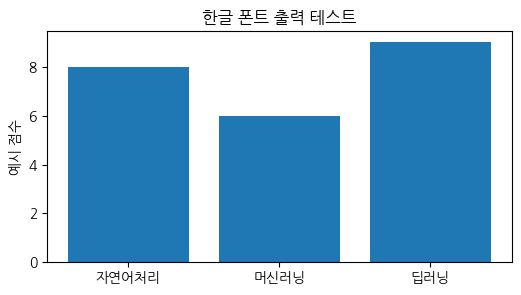

In [ ]:
# 한글 출력 테스트
categories = ["자연어처리", "머신러닝", "딥러닝"]
values = [8, 6, 9]

plt.figure(figsize=(6, 3))
plt.bar(categories, values)
#plt.bar(["자연어처리", "머신러닝", "딥러닝"], [8, 6, 9], color=["#4C78A8", "#F58518", "#54A24B"])

plt.title("한글 폰트 출력 테스트")
plt.ylabel("예시 점수")
plt.show()


## 5. Kiwi 형태소 분석기 테스트

Kiwi는 한국어 문장을 형태소 단위로 분석하는 도구입니다. 토큰화, 품사 태깅, 불용어 처리 등의 전처리에 활용할 수 있습니다.


In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("입력 문장:", text)
print("\n[형태소 분석 결과]")
for token in kiwi.tokenize(text):
    print(f"{token.form:10s} | {token.tag}")


입력 문장: 자연어처리 수업에서 한국어 텍스트를 분석합니다.

[형태소 분석 결과]
자연어 처리     | NNP
수업         | NNG
에서         | JKB
한국어        | NNP
텍스트        | NNG
를          | JKO
분석         | NNG
하          | XSV
ᆸ니다        | EF
.          | SF




```
"자연어처리"   명사(NNG)
"수업"         명사(NNG)
"에서"         부사격 조사(JKB)
"한국어"       명사(NNG)
"텍스트"       명사(NNG)
"를"           목적격 조사(JKO)
"분석"         명사(NNG) 어근
"하"           동사 파생 접미사(XSV) 또는 어미의 일부
"ㅂ니다"       종결 어미(EF)
"."            문장 종료를 나타내는 기호(SF)로 분석
```





```
NNG (일반 명사, Common Noun)

NNG는 특정한 고유한 대상을 지칭하지 않고 일반적인 사물, 개념, 현상을 나타내는 명사를 가리킵니다. 예를 들어 "책", "사람", "학교", "자연어처리", "텍스트" 같은 단어들이 여기에 해당합니다. 이런 명사들은 문장 안에서 누구나 사용할 수 있는 보통의 대상을 지칭하며, 대문자로 시작하거나 특별히 지정된 이름이 아니라는 점에서 고유 명사와 구분됩니다. 한국어 문장에서 가장 흔하게 등장하는 품사 중 하나이며, 문장의 핵심 의미를 담고 있는 경우가 많아서 키워드 추출이나 텍스트 요약 작업에서 특히 중요하게 다뤄지는 태그입니다.

NNP (고유 명사, Proper Noun)

NNP는 세상에 하나밖에 없는 특정한 대상, 즉 사람 이름, 지명, 회사명, 상표명, 국가명 같은 고유한 개체를 가리키는 명사입니다. 예를 들어 "서울", "삼성", "김철수", "한국" 같은 단어들이 이 태그로 분류됩니다. 일반 명사와 문법적으로는 비슷하게 작동하지만, 의미상 특정한 하나의 대상만을 가리킨다는 점에서 차이가 있습니다. 이 태그는 개체명 인식(Named Entity Recognition)이라는 자연어처리 작업과도 밀접하게 연결되어 있어서, 문서에서 인물이나 기관, 지역명을 추출하려는 경우 이 태그를 기준으로 필터링하는 경우가 많습니다.

JKO (목적격 조사, Objective Case Particle)

JKO는 문장에서 목적어 역할을 하는 명사 뒤에 붙어서 "그 명사가 동작의 대상이 된다"는 것을 표시해주는 조사입니다. 한국어에서는 "을"과 "를"이 대표적인 목적격 조사인데, 예를 들어 "텍스트를 분석합니다"에서 "를"이 바로 JKO에 해당합니다. 이 조사가 붙음으로써 "텍스트"라는 명사가 "분석하다"라는 동사의 목적어(무엇을 분석하는지)임을 문법적으로 명확히 드러내주는 역할을 합니다. 영어와 달리 한국어는 어순이 비교적 자유로운데, 이렇게 조사가 문장 성분(주어, 목적어 등)을 결정해주기 때문에 어순이 바뀌어도 의미가 크게 왜곡되지 않는 특징이 있습니다.

JKB (부사격 조사, Adverbial Case Particle)

JKB는 명사 뒤에 붙어서 그 명사가 부사어 역할을 하도록 만들어주는 조사로, 장소, 시간, 방향, 도구, 대상 등 다양한 의미 관계를 나타냅니다. "에서", "에", "로", "에게", "으로" 같은 조사들이 여기에 속합니다. 예를 들어 "수업에서 분석합니다"에서 "에서"는 "수업"이라는 장소적 배경을 나타내는 부사격 조사이며, "학교에 간다"에서 "에"는 이동의 목적지를 나타내는 부사격 조사입니다. 이처럼 JKB는 하나의 태그 안에서도 여러 세부 의미(장소, 시간, 방향, 수단 등)를 포괄하고 있어서, 실제로는 문맥에 따라 상당히 다양한 역할을 수행하는 조사군이라고 할 수 있습니다.

VV (동사 어간, Verb Stem)

VV는 동사의 실질적인 의미를 담고 있는 핵심 부분, 즉 어간을 가리키는 태그입니다. 한국어의 동사는 어간에 다양한 어미가 결합되어 활용되는 구조를 가지고 있는데, 예를 들어 "먹다", "먹는다", "먹었다", "먹으면" 등은 모두 "먹-"이라는 동일한 어간에 서로 다른 어미가 붙어 만들어진 형태입니다. 형태소 분석에서는 이렇게 활용된 동사를 어간과 어미로 분리해서, 어간 부분만 VV로 태깅하게 됩니다. 이 태그는 문장의 핵심 동작이나 사건을 담고 있기 때문에, 텍스트가 무엇을 서술하고 있는지 파악하는 데 중요한 역할을 합니다.

EF (종결 어미, Final Ending)

EF는 문장을 끝맺는 역할을 하는 어미로, 문장이 평서문인지 의문문인지 명령문인지, 그리고 격식체인지 비격식체인지 등을 결정하는 문법 요소입니다. 예를 들어 "분석합니다"에서 "ㅂ니다"가 EF에 해당하며, 이는 정중한 격식체 평서형 종결을 나타냅니다. "먹어요"의 "어요", "가자"의 "자", "왔니?"의 "니" 같은 것들도 모두 EF로 분류되는데, 각각 문장의 종류(청유형, 의문형 등)와 화자와 청자 간의 높임 관계를 함께 나타내주는 중요한 문법 표지입니다.

EC (연결 어미, Connective Ending)

EC는 문장을 끝내지 않고 다른 절이나 구와 연결시켜주는 어미로, 두 개 이상의 사건이나 상태를 하나의 문장 안에서 이어붙일 때 사용됩니다. 예를 들어 "밥을 먹고 학교에 갔다"에서 "먹고"의 "고"가 EC에 해당하며, 이는 앞의 동작과 뒤의 동작을 순차적으로 이어주는 역할을 합니다. "비가 오면 우산을 써라"의 "면"(조건), "공부하지만 성적이 안 오른다"의 "지만"(대조) 같은 것들도 모두 EC로 분류되며, 절과 절 사이의 논리적 관계(원인, 조건, 대조, 나열 등)를 문법적으로 명시해주는 기능을 합니다.

XSV (동사 파생 접미사, Verb-deriving Suffix)

XSV는 원래 동사가 아니었던 명사나 어근에 붙어서 그것을 동사로 바꿔주는 접미사를 가리킵니다. 대표적인 예가 "하다"의 "하-" 부분인데, 예를 들어 "분석"이라는 명사에 "하"가 붙어 "분석하다"라는 동사가 만들어지는 경우, 이때의 "하"가 XSV로 태깅됩니다. 즉 "분석합니다"라는 어절은 분석 과정에서 "분석"(명사, NNG)과 "하"(동사 파생 접미사, XSV), 그리고 "ㅂ니다"(종결 어미, EF)로 세분화될 수 있습니다. 이런 "명사+하다" 구조는 한국어에서 매우 흔하게 나타나는 동사 생성 방식이며, "공부하다", "운동하다", "사랑하다" 등 수많은 동사들이 이러한 방식으로 명사에 XSV가 결합되어 만들어집니다.

전체적으로 정리하면

이 여덕 가지 태그를 큰 범주로 나눠보면, NNG와 NNP는 명사류로서 문장의 대상이나 주제를 나타내고, JKO와 JKB는 조사류로서 그 명사가 문장 안에서 어떤 문법적 역할(목적어인지, 부사어인지)을 하는지를 표시해줍니다. VV는 동사의 핵심 의미를 담은 어간이고, XSV는 명사를 동사로 변신시켜주는 접미사이며, EF와 EC는 각각 문장을 끝맺거나 다른 절로 이어붙이는 어미로서 문장의 구조와 흐름을 결정짓는 역할을 합니다. 이렇게 형태소 하나하나에 세밀한 문법적 역할이 부여되기 때문에, 한국어 자연어처리에서는 단순히 띄어쓰기로 단어를 나누는 것만으로는 부족하고, 이런 형태소 단위의 분석이 반드시 필요하게 됩니다.
```



In [ ]:
# 명사만 간단히 추출해 보기
nouns = [token.form for token in kiwi.tokenize(text) if token.tag.startswith("N")]
print("명사:", nouns)


명사: ['자연어 처리', '수업', '한국어', '텍스트', '분석']


In [ ]:
nouns = []
for token in kiwi.tokenize(text):
    if token.tag.startswith("N"):
        nouns.append(token.form)

print("명사:", nouns)


명사: ['자연어 처리', '수업', '한국어', '텍스트', '분석']


## 6. KoNLPy 테스트

KoNLPy는 여러 한국어 형태소 분석기를 파이썬에서 사용할 수 있게 해주는 라이브러리입니다. 환경에 따라 일부 분석기는 Java 설정을 요구할 수 있으므로, 이번 실습에서는 비교적 간단하게 사용할 수 있는 `Okt`를 테스트합니다.


In [ ]:
from konlpy.tag import Okt

okt = Okt()
text = "자연어처리 수업에서 한국어 텍스트를 분석합니다."

print("형태소:", okt.morphs(text))
print("명사  :", okt.nouns(text))
print("품사  :", okt.pos(text))


형태소: ['자연어', '처리', '수업', '에서', '한국어', '텍스트', '를', '분석', '합니다', '.']
명사  : ['자연어', '처리', '수업', '한국어', '텍스트', '분석']
품사  : [('자연어', 'Noun'), ('처리', 'Noun'), ('수업', 'Noun'), ('에서', 'Josa'), ('한국어', 'Noun'), ('텍스트', 'Noun'), ('를', 'Josa'), ('분석', 'Noun'), ('합니다', 'Verb'), ('.', 'Punctuation')]


In [ ]:
# TODO 5. 본인이 작성한 문장으로 형태소 분석을 수행하세요.
my_sentence = "안녕하세요 자연언어처리 수업당담 임화정 교수입니다."

print("문장:", my_sentence)
print("Kiwi:", [(t.form, t.tag) for t in kiwi.tokenize(my_sentence)])
print("Okt :", okt.pos(my_sentence))  # TODO: Okt 품사 분석 결과를 출력하세요.

문장: 안녕하세요 자연언어처리 수업당담 임화정 교수입니다.
Kiwi: [('안녕', 'NNG'), ('하', 'XSA'), ('세요', 'EF'), ('자연', 'NNG'), ('언어', 'NNG'), ('처리', 'NNG'), ('수업', 'NNG'), ('당', 'XSN'), ('담', 'NNG'), ('임화정', 'NNP'), ('교수', 'NNG'), ('이', 'VCP'), ('ᆸ니다', 'EF'), ('.', 'SF')]
Okt : [('안녕하세요', 'Adjective'), ('자연언어', 'Noun'), ('처리', 'Noun'), ('수업', 'Noun'), ('당', 'Modifier'), ('담', 'Noun'), ('임화', 'Noun'), ('정', 'Noun'), ('교수', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation')]


Kiwi 명사 어근, 동사 파생 접미사, 종결 어미로 세 조각을 내어 각각 다른 형태소로 인식하는 경우

Okt(Open Korean Text) 활용된 용언(동사나 형용사)을 어간과 어미로 잘게 쪼개지 않고, 활용된 형태 그대로를 하나의 통짜 토큰으로 처리하는 경향

Kiwi는 사전에 등재된 하나의 명사로 처리할 수 있는 반면, Okt는 이를 자연어(Noun)와 처리(Noun)처럼 두 개의 개별 명사로 쪼개어 인식하는 경우

## 7. 간단한 텍스트 전처리 실습

문장을 소문자화하고, 특수문자를 제거한 뒤 공백 기준으로 토큰화합니다. 한국어에서는 이후 형태소 분석을 활용한 토큰화가 더 유용합니다.


In [ ]:
import re

sample = "NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)"
cleaned = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", sample)
cleaned = re.sub(r"\s+", " ", cleaned).strip().lower()
tokens = cleaned.split()

print("원문       :", sample)
print("정제 결과  :", cleaned)
print("토큰       :", tokens)


원문       : NLP 실습은 재미있습니다! 2026년에도 꾸준히 학습해 봅시다. :)
정제 결과  : nlp 실습은 재미있습니다 2026년에도 꾸준히 학습해 봅시다
토큰       : ['nlp', '실습은', '재미있습니다', '2026년에도', '꾸준히', '학습해', '봅시다']


## 8. GitHub로 실습 코드 관리

강의에서는 실습 코드와 프로젝트 산출물을 GitHub에 축적하여 포트폴리오로 관리하는 것을 권장합니다.

### 최초 1회 설정 (로컬 환경 또는 Colab)

아래 명령에서 이름과 이메일을 본인 정보로 바꿉니다. 토큰·비밀번호 등 민감정보는 노트북에 직접 작성하거나 공개 저장소에 올리지 마세요.


In [ ]:
# ── 1단계: Git 사용자 정보 설정 ──
# 아래 주석을 해제하고 본인 정보로 수정하세요.
#!git config --global user.name "임화정"
#!git config --global user.email "cute0progt@google.com"

# 현재 설정 확인
!git config --global --list


user.name=임화정
user.email=cute0progt@google.com


In [ ]:
# ── 2단계: 이미 만들어둔 GitHub 저장소를 Colab으로 복제(clone) ──
# GitHub에서 README를 포함해서 저장소를 이미 생성했으므로,
# git init이 아니라 git clone으로 시작해야 충돌이 나지 않습니다.
!git clone https://github.com/cute0prog/CBNU_NLP.git


Cloning into 'CBNU_NLP'...
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
# ── 3단계: 작업 폴더를 클론한 저장소 안으로 이동 ──
import os
os.chdir('/content/CBNU_NLP')

# 현재 경로가 잘 옮겨졌는지 확인
!pwd

In [ ]:
# ── 4단계: 업로드했던 실습 파일을 이 폴더 안으로 이동 ──
# 예: Colab에 직접 업로드한 파일이 /content/ 아래에 있는 경우
import shutil
shutil.move('/content/업로드한파일명.ipynb', '/content/CBNU_NLP/업로드한파일명.ipynb')

# 만약 구글 드라이브에 있는 파일을 가져오는 경우라면 아래처럼 사용
# from google.colab import drive
# drive.mount('/content/drive')
# shutil.copy('/content/drive/MyDrive/폴더명/파일명.ipynb', '/content/CBNU_NLP/파일명.ipynb')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/cute0prog/CBNU_NLP.git

import shutil
shutil.copy('/content/drive/MyDrive/01_CBNU/자연언어처리/실습/NLP_week01.ipynb', '/content/CBNU_NLP/NLP_week01.ipynb')

import os
os.chdir('/content/CBNU_NLP')

!git add .
!git commit -m "chore: initialize NLP practice environment"
!git push


## 9. 환경 점검 체크리스트

아래 항목을 모두 확인했다면 1주차 환경 구축이 완료되었습니다.

- [ ] Colab에서 노트북을 실행했다.
- [ ] Python 및 핵심 라이브러리 버전을 확인했다.
- [ ] 한글 그래프가 정상적으로 출력된다.
- [ ] Kiwi로 형태소와 품사를 분석했다.
- [ ] KoNLPy `Okt`가 정상적으로 동작한다.
- [ ] GitHub 저장소 또는 코드 관리 계획을 준비했다.

---

### 제출/기록용 미니 과제
자신이 관심 있는 한국어 문장 2개를 정하고, Kiwi 또는 Okt로 토큰화한 결과를 출력해 보세요. 실행 결과와 함께 노트북을 GitHub 저장소에 기록합니다.


In [ ]:
# 미니 과제: 아래 문장을 바꿔서 형태소 분석 결과를 확인하세요.
my_sentences = [
    "인공지능은 다양한 산업을 변화시키고 있습니다.",
    "자연어처리 실습 환경을 성공적으로 구축했습니다."
]

for sentence in my_sentences:
    print(f"\n문장: {sentence}")
    print("Kiwi:", [(t.form, t.tag) for t in kiwi.tokenize(sentence)])
    print("Okt :", okt.pos(sentence))


## 다음 주차 예고

다음 실습에서는 텍스트 데이터의 구조를 살펴보고, 정제·토큰화·불용어 처리 등 **한국어 텍스트 전처리**를 본격적으로 다룹니다.


In [ ]:
# 필요한 라이브러리 설치
# Colab에서는 매 세션마다 재설치가 필요합니다.

!pip install -q konlpy wordcloud matplotlib

## 과제 제출안내

### 제출/기록용 미니 과제

자신이 관심 있는 한국어 문장 2개를 정하고, Kiwi 또는 Okt로 토큰화한 결과를 출력해 보세요. 실행 결과와 함께 노트북을 GitHub 저장소에 기록합니다.
- GitHub 계정 생성 및 저장소(repo) 만들기
   - 저장소 이름: `NLP-2026`
   - 이번 주 노트북 업로드

### 제출 방법

- 파일명: `NLP_week01_[학번].ipynb`
- 제출처: LMS 과제 게시판

### 주의사항

- 늦은 제출 **불가**
- 제출 기한: **다음 주 수업 전까지**
- GitHub 저장소 링크도 함께 제출

## 다음 주 예고

### 2주차: 자연어와 텍스트 데이터 이해

다음 실습에서는 자연어와 텍스트 데이터의 특성을 이해하고, 정형·반정형·비정형 데이터의 차이, UTF-8 인코딩과 한글 정규화(NFC/NFD), 데이터 품질·윤리, 기초 텍스트 탐색 분석(EDA)을 다룹니다.
이후 주차에서 토큰화·불용어 제거·어간 추출 등 한국어 텍스트 전처리를 본격적으로 학습합니다.

### 미리 준비할 것

-  GitHub 계정 생성 완료
-  Colab 환경 설정 완료
-  1주차 과제 제출 완료